In [62]:
import torch
from torch import nn
import numpy as np
import pandas as pd
from torchvision import transforms, utils
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from typing import List , Union
import torch.functional as F
from tqdm import tqdm

In [17]:
pd_mnist = pd.read_csv("mnist_test.csv")
pd_mnist_test = pd.read_csv("mnist_test.csv")

In [18]:
print(f"{pd_mnist.shape=}")
print(f"{pd_mnist_test.shape=}")

pd_mnist.shape=(9999, 785)
pd_mnist_test.shape=(9999, 785)


In [20]:
mnist_dataset = torch.from_numpy(pd_mnist.to_numpy())
mnist_dataset

tensor([[2, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [4, 0, 0,  ..., 0, 0, 0],
        [5, 0, 0,  ..., 0, 0, 0],
        [6, 0, 0,  ..., 0, 0, 0]])

In [21]:
print(mnist_dataset.shape)

torch.Size([9999, 785])


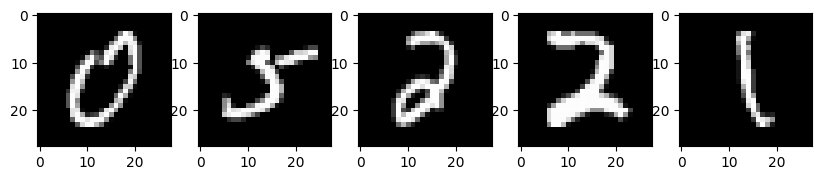

In [22]:
def visualize_mnist(mnist_tensor : torch.tensor, num_plots = 5) -> None:
  "plots num_plots random plots"
  # select random batch
  indices = np.random.choice(mnist_tensor.shape[0],size = num_plots)
  mnist_tensor = mnist_tensor[indices]
  number_class = mnist_tensor[:,0]
  number_image = mnist_tensor[:,1:].reshape(-1,28,28)
  plt.figure(figsize=(10,5))
  for i in range(num_plots):
    plt.subplot(1,num_plots,i+1)
    # plt.xlabel(f"Mnist number located at index {indices[i]}")
    plt.imshow(number_image[i],label = number_class[i],cmap="gray",vmin=0,vmax=255)

  plt.show()
visualize_mnist(mnist_tensor=mnist_dataset,num_plots=5)

In [34]:
class MnistDataset(Dataset):
    """Mnist dataset"""
    def __init__(self,csv_file,transforms = None):
        super().__init__()
        self.mnist = pd.read_csv(csv_file)
        self.transform = transforms
    
    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, index):
        """Returns image label pair"""
        if torch.is_tensor(index):
            index = index.tolist()
        label = self.mnist.iloc[index, 0]
        # C, H, W -> 1, 28,28
        image = self.mnist.iloc[index,1:].to_numpy(dtype=np.float32).reshape(1,28,28) 
        
        if self.transform:
            image = self.transform(image)
        return image , label



In [35]:
mnist_train = MnistDataset("mnist_train_small.csv")

In [36]:
for image, label in (mnist_train):
    print( image.shape, label.shape)
    break

(1, 28, 28) ()


In [37]:
exampler_loader = DataLoader(mnist_train,batch_size=5,shuffle=True,num_workers=0)

In [38]:
for i, (X, y) in enumerate(exampler_loader):
    print(i, X.shape, y.shape)
    
    break

0 torch.Size([5, 1, 28, 28]) torch.Size([5])


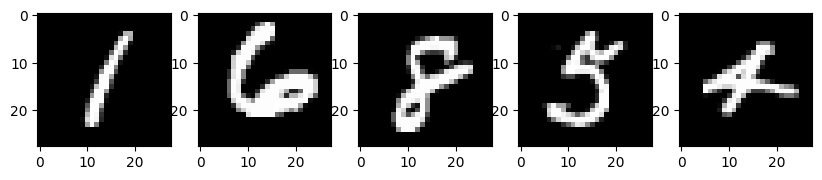

In [93]:
def visualize_mnist_loader(mnist_tensor : torch.Tensor, num_to_plot = 5) -> None:
  """Visualize Mnist using dataloader type
  Mnist tensors are batched batched"""
  # select random batch
  indices = range(mnist_tensor.shape[0])
  
  mnist_tensor = mnist_tensor[indices].squeeze(1).cpu()
  plt.figure(figsize=(10,5))
  for i in range(num_to_plot):
    plt.subplot(1,num_to_plot,i+1)
    # plt.xlabel(f"Mnist number located at index {indices[i]}")
    plt.imshow(mnist_tensor[i],cmap="gray",vmin=0,vmax=255)

  plt.show()
for i, (X , y) in enumerate(exampler_loader):
    
    visualize_mnist_loader(mnist_tensor=X,num_to_plot=5)
    break


In [124]:
# define device 
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

class FCN(nn.Module):
    def __init__(self,num_layers =1):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(28*28,100)
        self.relu = nn.ReLU()
        self.linear_relu = nn.Sequential(*[nn.Linear(100,100),nn.ReLU()]*num_layers)
        self.out = nn.Linear(100,10)

    def forward(self,x):
        x = self.flatten(x)
        x = self.relu(self.linear1(x))
        x = self.linear_relu(x)
        x = self.out(x)
        return x 


Using mps device


In [125]:
def train(dataloader,model,loss_fn,optimizer):
    train_losses = []
    model.train()
    size = len(dataloader.dataset)
    for i, (X,y) in (enumerate(dataloader)):
        X,y = X.to(device),y.to(device)
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred,y)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        if i %1000==0:
            loss,current = loss.item(), (i+1)*len(X)
            print(f"Loss: {loss:5f} | {current}/{size}")
    return train_losses

def test(dataloader,model,loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss,correct = 0,0
    (test_losses) = []
    with torch.no_grad():
        for X,y in dataloader:
            X, y = X.to(device), y.to(device)

            preds = model(X)
            loss = loss_fn(preds,y)

            test_loss += loss.item()
            correct += (y==preds.argmax(1)).type(torch.float32).sum().item()
    
    test_loss /=num_batches
    test_losses.append(test_loss)
    accuracy = correct /size
    print(f"Test Error: \n Accuracy: {(100*accuracy):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_losses
mnist_test = MnistDataset("mnist_test.csv")
def train_model(model,epochs,batch_size):
    train_loader = DataLoader(mnist_train,batch_size,shuffle=True)
    test_loader = DataLoader(mnist_test,batch_size)
    loss_fn = nn.CrossEntropyLoss() # averages by default
    opt = torch.optim.SGD(model.parameters(),lr=1e-3)
    all_train_losses = []
    all_test_losses = []
    for t in range(epochs):
        print(f"Epoch: {t}")
        tr_l = train(train_loader,model,loss_fn,opt)
        all_train_losses.append(np.mean(tr_l))
        te_l = test(test_loader,model,loss_fn)
        all_test_losses.extend(te_l)
    plt.figure()

    plt.plot(np.array(all_train_losses),'r-o',label='Train')

    plt.plot(np.array(all_test_losses),'b-o',label = 'Test')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title("Training and test Loss")
    plt.show()

89610
Epoch: 0
Loss: 9.634260 | 32/19999
Test Error: 
 Accuracy: 90.6%, Avg loss: 0.323936 

Epoch: 1
Loss: 0.203935 | 32/19999
Test Error: 
 Accuracy: 92.6%, Avg loss: 0.247174 

Epoch: 2
Loss: 0.051761 | 32/19999
Test Error: 
 Accuracy: 93.2%, Avg loss: 0.221825 

Epoch: 3
Loss: 0.034647 | 32/19999
Test Error: 
 Accuracy: 94.0%, Avg loss: 0.195801 

Epoch: 4
Loss: 0.066402 | 32/19999
Test Error: 
 Accuracy: 94.3%, Avg loss: 0.194949 



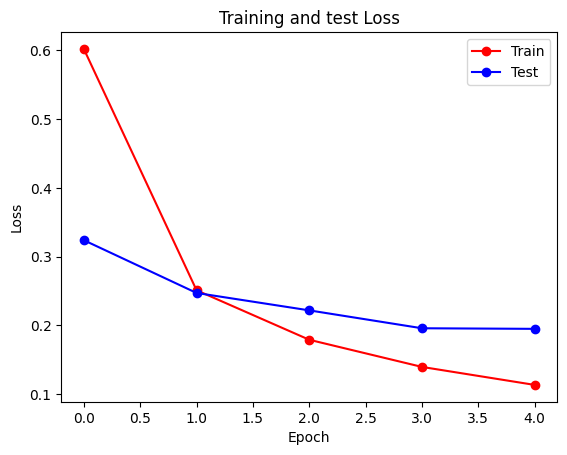

In [126]:
simple_fcn = FCN(num_layers=1).to(device)
print(sum(p.numel() for p in simple_fcn.parameters()))
train_model(simple_fcn,5,32)

In [77]:
print(simple_fcn(torch.rand([1,28,28],device=device)).shape)

torch.Size([1, 10])


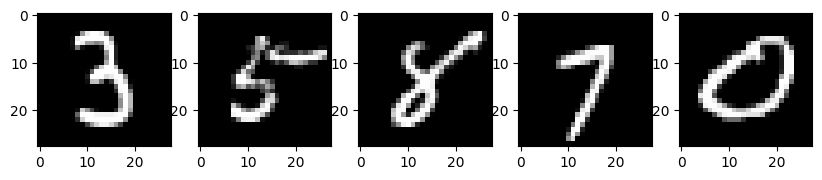

tensor([3, 5, 8, 7, 0])
tensor([3, 5, 8, 7, 0], device='mps:0')


In [123]:
for i, (X,y) in enumerate(DataLoader(mnist_test,5,shuffle=True)):
    X = X.to(device)
    visualize_mnist_loader(X)
    print(y)
    print(simple_fcn(X).argmax(1))
    break